# Subpoblaciones de NMR

Durante `01_analysis` se encontró que el coeficiente de variación de `CHOL body` es el más alto comparado con las otras regiones (~41-20x para **Mouse** y **NMR** respectivamente). Con esto, se propone analizar el grupo **NMR** para la identificación de subpoblaciones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

warnings.filterwarnings("ignore")

/home/dylanhr/miniconda3/envs/cimat_mouse/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cargar datos

In [2]:
%%time
# Estructura de datos
data: dict[str, dict[str, np.ndarray]] = {}

# Solo cargar datos de NMR
target_folders = ["NMR"]

# Extraer archivos .npy
for folder_name in target_folders:
    sub_folder = Path("..") / folder_name

    if sub_folder.is_dir():
        data[sub_folder.name] = {
            file.stem: np.load(file) for file in sub_folder.glob("*.npy")
        }

# Obtener información sobre valores nulos, valores infinitos, tipo de dato y forma
for d in data:
    for lipid in data[d]:
        array = data[d][lipid]
        nans = np.isnan(array).sum()
        infs = np.isinf(array).sum()
        dtype = array.dtype
        shape = array.shape
        print(
            f"Array {d} {lipid}: nans={nans}, infs={infs}, dtype={dtype}, shape={shape}"
        )

Array NMR g3_DPSM_heads_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array NMR g3_DPSM_tails: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR artificial_volume: nans=0, infs=0, dtype=float64, shape=(1,)
Array NMR g3_DPSM_heads: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR g3_CHOL_head: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
Array NMR g3_CHOL_head_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array NMR g3_DPSM_tails_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array NMR g3_CHOL_body_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array NMR g3_CHOL_body: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
CPU times: user 148 ms, sys: 2.85 s, total: 2.99 s
Wall time: 3.01 s


Solamente se utilizarán características de `CHOL body` para **NMR**. Además, se agrega una nueva característica del coeficiente de variación (`std_body / mean_body`).

In [3]:
nmr_chol_body_feats = []
body_data = data["NMR"]["g3_CHOL_body"]

n_molecules = body_data.shape[0]
for i in range(n_molecules):
    mean_body = np.mean(body_data[i, :, :])
    std_body = np.std(body_data[i, :, :])
    min_body = np.min(body_data[i, :, :])
    max_body = np.max(body_data[i, :, :])

    dict_feats = {
        "mean_body": mean_body,
        "std_body": std_body,
        "range_body": max_body - min_body,
        "cv_body": std_body / mean_body,
    }

    nmr_chol_body_feats.append(dict_feats)

In [4]:
df_nmr_chol_body = pd.DataFrame(nmr_chol_body_feats)
df_nmr_chol_body.head()

,mean_body,std_body,range_body,cv_body
0,0.000021,0.000432,0.058305,20.789230
1,0.000017,0.000432,0.058219,26.101698
2,0.000021,0.000432,0.058261,21.044260
3,0.000021,0.000432,0.058256,20.823084
4,0.000022,0.000432,0.058326,19.243490


In [5]:
df_nmr_chol_body.describe()

,mean_body,std_body,range_body,cv_body
count,342.000000,342.000000,342.000000,342.000000
mean,0.000022,0.000432,0.058228,20.323452
std,0.000004,0.000001,0.000091,3.418835
min,0.000012,0.000418,0.057427,12.448402
25%,0.000019,0.000432,0.058187,18.099811
50%,0.000021,0.000432,0.058244,20.782499
75%,0.000024,0.000432,0.058283,22.190523
max,0.000035,0.000432,0.058380,34.582742


## Preparación de features

`mean_body`, `std_body`, `range_body` y `cv_body` están en escalas muy distintas (`cv_body` ~20, `mean_body` ~1e-5). Se utiliza `StandardScaler` antes de continuar para que `cv_body` no domine el resultado.

In [6]:
X_raw = df_nmr_chol_body.copy()
X_scaled = StandardScaler().fit_transform(X_raw)

print(f"Features usadas: {list(X_raw.columns)}")
print(f"X_scaled shape: {X_scaled.shape}")

Features usadas: ['mean_body', 'std_body', 'range_body', 'cv_body']
X_scaled shape: (342, 4)


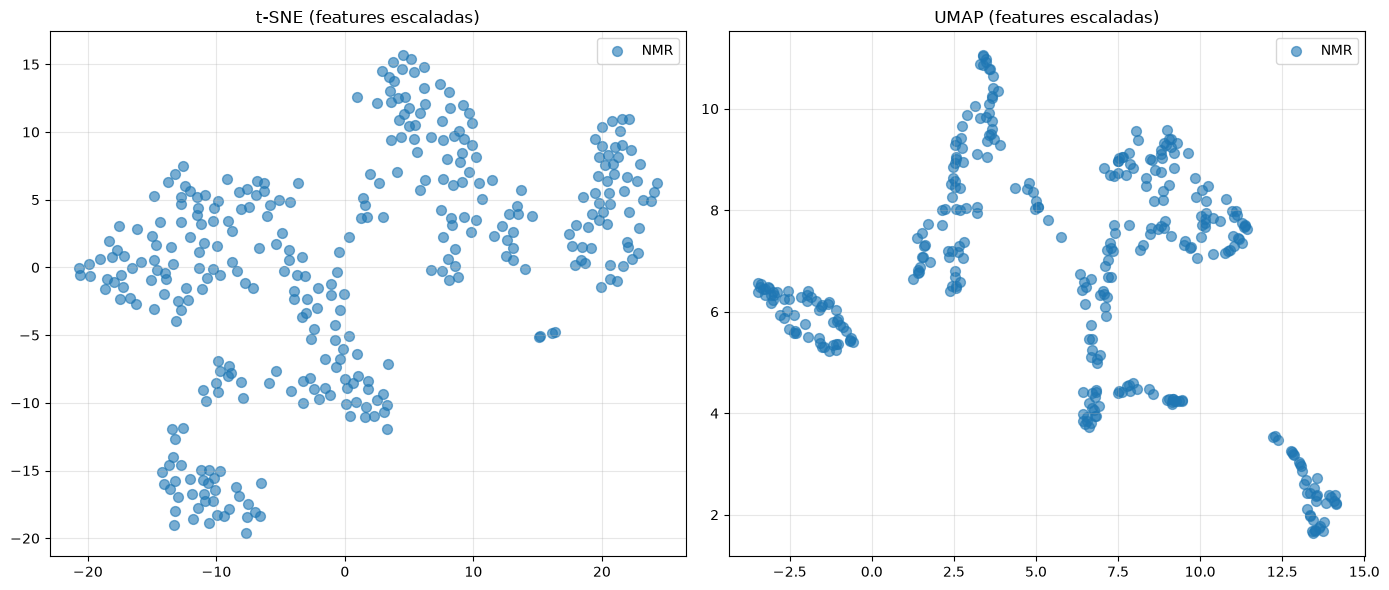

CPU times: user 15.9 s, sys: 704 ms, total: 16.6 s
Wall time: 9.16 s


In [7]:
%%time
embedding_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    X_scaled
)
embedding_umap = UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    embedding_tsne[:, 0], embedding_tsne[:, 1], label="NMR", alpha=0.6, s=50
)
axes[0].set_title("t-SNE (features escaladas)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    embedding_umap[:, 0], embedding_umap[:, 1], label="NMR", alpha=0.6, s=50
)
axes[1].set_title("UMAP (features escaladas)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Selección del número de clústers

Se prueban tres algoritmos directamente sobre `X_scaled`: `KMeans`, `AgglomerativeClustering` (linkage `ward`) y `GaussianMixture` (`GMM`). Para elegir *k* se usa el método del codo (inercia), silhouette para KMeans/Agglomerative, y BIC/AIC para GMM.

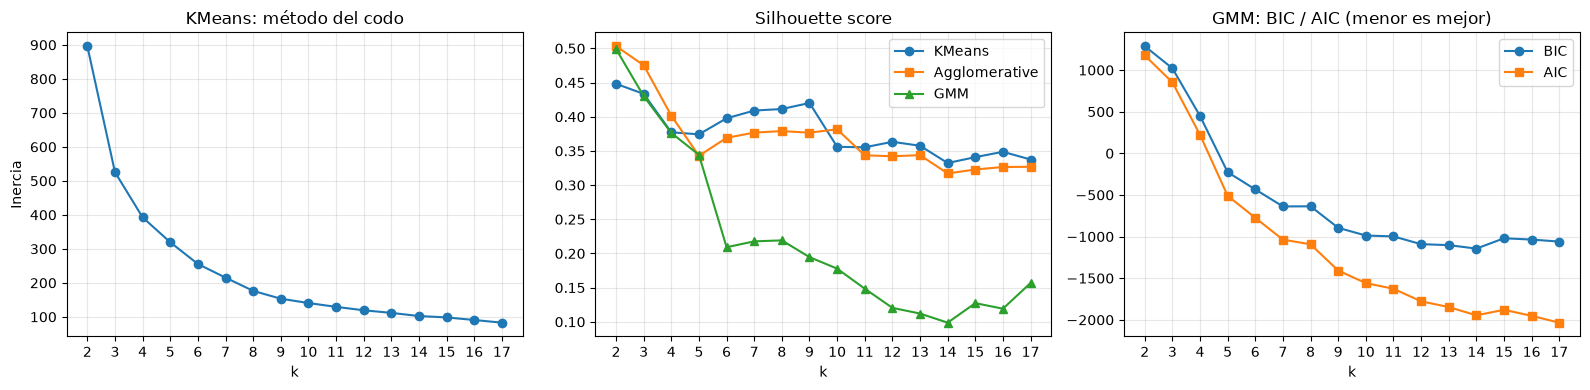

CPU times: user 57.4 s, sys: 3.19 s, total: 1min
Wall time: 8.05 s


,k,kmeans_inertia,silhouette_kmeans,silhouette_agglomerative,silhouette_gmm,gmm_bic,gmm_aic
0,2,896.175336,0.448204,0.503279,0.499024,1287.145256,1175.935745
1,3,525.479650,0.433466,0.475378,0.430185,1021.404967,852.673294
2,4,392.699325,0.377280,0.401598,0.376320,448.330328,222.076494
3,5,319.400154,0.374274,0.342888,0.344277,-226.446592,-510.222586
4,6,255.477734,0.397737,0.369140,0.209146,-433.814712,-775.112868
5,7,215.372619,0.409077,0.376794,0.217712,-638.196256,-1037.016572
6,8,176.409669,0.411321,0.379016,0.219159,-636.628132,-1092.970610
7,9,153.366146,0.420159,0.376732,0.194642,-894.936440,-1408.801079
8,10,140.691337,0.356055,0.381645,0.177814,-987.544783,-1558.931583
9,11,129.393051,0.355325,0.343568,0.148494,-998.212085,-1627.121046


In [78]:
%%time
k_range = range(2, 18)

inertias, sil_kmeans, sil_agg = [], [], []
bics, aics, sil_gmm = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_kmeans.append(silhouette_score(X_scaled, km.labels_))

    agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X_scaled)
    sil_agg.append(silhouette_score(X_scaled, agg.labels_))

    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
    sil_gmm.append(silhouette_score(X_scaled, gmm.predict(X_scaled)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("KMeans: método del codo")
axes[0].set_xticks(list(k_range))
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_kmeans, marker="o", label="KMeans")
axes[1].plot(list(k_range), sil_agg, marker="s", label="Agglomerative")
axes[1].plot(list(k_range), sil_gmm, marker="^", label="GMM")
axes[1].set_title("Silhouette score")
axes[1].set_xticks(list(k_range))
axes[1].set_xlabel("k")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(k_range), bics, marker="o", label="BIC")
axes[2].plot(list(k_range), aics, marker="s", label="AIC")
axes[2].set_title("GMM: BIC / AIC (menor es mejor)")
axes[2].set_xticks(list(k_range))
axes[2].set_xlabel("k")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "k": list(k_range),
        "kmeans_inertia": inertias,
        "silhouette_kmeans": sil_kmeans,
        "silhouette_agglomerative": sil_agg,
        "silhouette_gmm": sil_gmm,
        "gmm_bic": bics,
        "gmm_aic": aics,
    }
)

In [76]:
print("Cambio en porcentaje para inercia:")
np.diff(np.array(inertias[1:])) / np.diff(np.array(inertias[:-1])) 

Cambio en porcentaje para inercia:


array([0.35819226, 0.55203337, 0.87207563, 0.62740295, 0.97152074,
       0.5914214 , 0.5500378 , 0.89139694, 0.88665275, 0.76700216,
       1.21372514, 0.42757267, 1.9119225 , 1.03171375])

La inercia en `KMeans` muestra que el _k_ óptimo está entre 2-4, según el método del codo. En el cambio de porcentaje para inercia podemos ver que de 3 a 4 para _k_ hay un _ratio_ de ~0.36. Sugiriendo que el cuarto clúster solo aportó un tercio de lo que mejoró el tercero.  

Aunque el `silhouette_score` tiene un máximo para _k_=2 para los tres algoritmos, _k_=3 todavía es candidato con un cambio en porcentaje mínimo (Kmeans: -3.3%, Agglomerative: -5.5%, GMM -13.8%) comparando con _k_=2. En _k_=5 `silhouette_score` decrementa y no vuelve a alcanzar un valor superando al rango _k_=[2,3].  

`BIC` y `AIC` no muestran un mínimo claro, decrementando monótonamente. Muestra una caída fuerte de _k_=2 a _k_=6. Sin embargo, comparando la gráfica de `silhouette_score` para `GMM` podemos ver que para _k_>=5 los resultados empeoran.  

En conclusión, se escoge _k_=2 y _k_=3 como mejores candidato para el análisis, debido a que muestran los dos mejores `silhouette_score` para los tres algoritmos y además una señal favorable en el método del codo.

## Clustering final y comparación entre algoritmos

Se ajustan los tres algoritmos con _k_=2 y _k_=3 (óptimos encontrados en el análisis anterior) para comparar directamente entre sí.

In [79]:
for k in (2, 3):
    labels_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(
        X_scaled
    )
    labels_agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(
        X_scaled
    )
    labels_gmm = (
        GaussianMixture(n_components=k, random_state=42, n_init=5)
        .fit(X_scaled)
        .predict(X_scaled)
    )

    print(f"Tamaño de clústers (k={k}):")
    print("KMeans:        ", np.bincount(labels_kmeans))
    print("Agglomerative: ", np.bincount(labels_agg))
    print("GMM:           ", np.bincount(labels_gmm))

    print("\nAcuerdo entre algoritmos (Adjusted Rand Index, 1.0 = idéntico, ~0.0 = azar):")
    print(f"KMeans vs Agglomerative: {adjusted_rand_score(labels_kmeans, labels_agg):.3f}")
    print(f"KMeans vs GMM:           {adjusted_rand_score(labels_kmeans, labels_gmm):.3f}")
    print(f"Agglomerative vs GMM:    {adjusted_rand_score(labels_agg, labels_gmm):.3f}")
    print("====================================")

Tamaño de clústers (k=2):
KMeans:         [ 99 243]
Agglomerative:  [ 64 278]
GMM:            [ 63 279]

Acuerdo entre algoritmos (Adjusted Rand Index, 1.0 = idéntico, ~0.0 = azar):
KMeans vs Agglomerative: 0.605
KMeans vs GMM:           0.574
Agglomerative vs GMM:    0.932
Tamaño de clústers (k=3):
KMeans:         [208 130   4]
Agglomerative:  [278  60   4]
GMM:            [203 135   4]

Acuerdo entre algoritmos (Adjusted Rand Index, 1.0 = idéntico, ~0.0 = azar):
KMeans vs Agglomerative: 0.350
KMeans vs GMM:           0.943
Agglomerative vs GMM:    0.320


In [80]:
def pct_neg(s: pd.Series):
    return s[s < 0].count() / s.count()

for k in (2, 3):
    labels_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(
        X_scaled
    )
    labels_agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(
        X_scaled
    )
    labels_gmm = (
        GaussianMixture(n_components=k, random_state=42, n_init=5)
        .fit(X_scaled)
        .predict(X_scaled)
    )

    sil_samp_kmeans = silhouette_samples(X_scaled, labels_kmeans)
    sil_samp_agg = silhouette_samples(X_scaled, labels_agg)
    sil_samp_gmm = silhouette_samples(X_scaled, labels_gmm)

    df_sil_kmeans = pd.DataFrame({
        "silhouette": sil_samp_kmeans,
        "label": labels_kmeans
    })
    df_sil_kmeans["method"] = "kmeans"

    df_sil_agg = pd.DataFrame({
        "silhouette": sil_samp_agg,
        "label": labels_agg
    })
    df_sil_agg["method"] = "agg"

    df_sil_gmm = pd.DataFrame({
        "silhouette": sil_samp_gmm,
        "label": labels_gmm
    })
    df_sil_gmm["method"] = "gmm"

    df_sil = pd.concat([df_sil_kmeans, df_sil_agg, df_sil_gmm])

    print(df_sil.groupby(["label", "method"]).agg(["count", "mean", "std", "min", pct_neg]))

             silhouette                                        
                  count      mean       std       min   pct_neg
label method                                                   
0     agg            64  0.303094  0.135569 -0.013521  0.015625
      gmm            63  0.276659  0.167309 -0.374543  0.031746
      kmeans         99  0.265194  0.186306 -0.146912  0.111111
1     agg           278  0.549365  0.154985  0.012950  0.000000
      gmm           279  0.549235  0.157538 -0.023682  0.007168
      kmeans        243  0.522763  0.142866  0.110988  0.000000
             silhouette                                        
                  count      mean       std       min   pct_neg
label method                                                   
0     agg           278  0.468868  0.210173 -0.219365  0.057554
      gmm           203  0.482471  0.116411  0.081929  0.000000
      kmeans        208  0.476986  0.127901  0.039694  0.000000
1     agg            60  0.505604  0.105

En el número de muestras dentro de cada clúster podemos ver que para k=2 `AgglomerativeClustering` y `GaussianMixture` son muy similares (concuerda con **Adjusted Rand Index** entre estos dos métodos de 0.932). Ambos en promedio tienen un `silhouette_score` de ~0.27-0.30 y ~0.52-0.55 para clúster 0 y clúster 1 respectivamente. Sin embargo, se puede ver que dentro de los clústers existen valores negativos (`pct_neg`), alcanzando hasta 11.11% en `KMeans`. Comparando ambas medias, se tiene que el clúster 0 es más débil frente a clúster 1.  

Para k=3 en promedio, `silhouette_score` es más alto (~0.35-0.51). Hubo mayor acuerdo entre `KMeans` y `GaussianMixture` con **Adjusted Rand Index** de 0.943. Aparece un clúster muy pequeño con apenas 4 elementos, lo cual también explica la razón de un alto `silhouette_score`.

## Visualización

Los clústers con valores de k=[2,3] se calcularon sobre `X_scaled` (4 features), no sobre el embedding 2D. t-SNE/UMAP aquí solo sirven para visualizar, coloreando cada punto según la etiqueta que le asignó cada algoritmo para cada valor _k_.

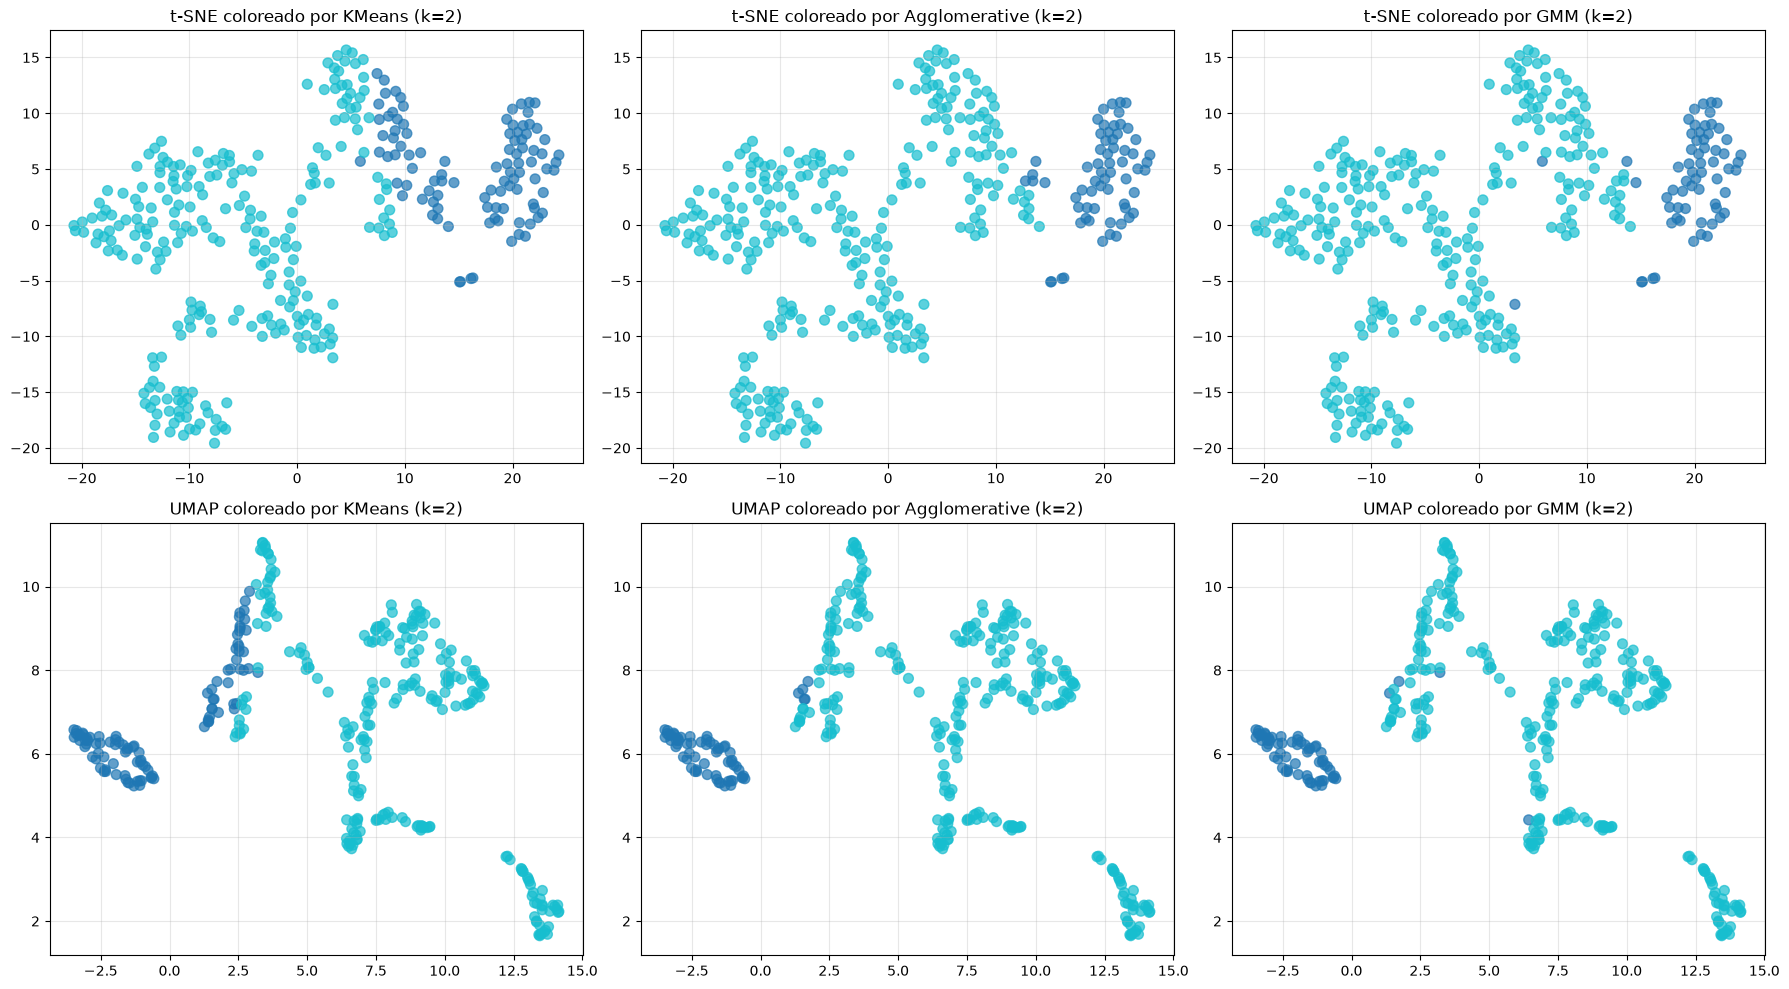

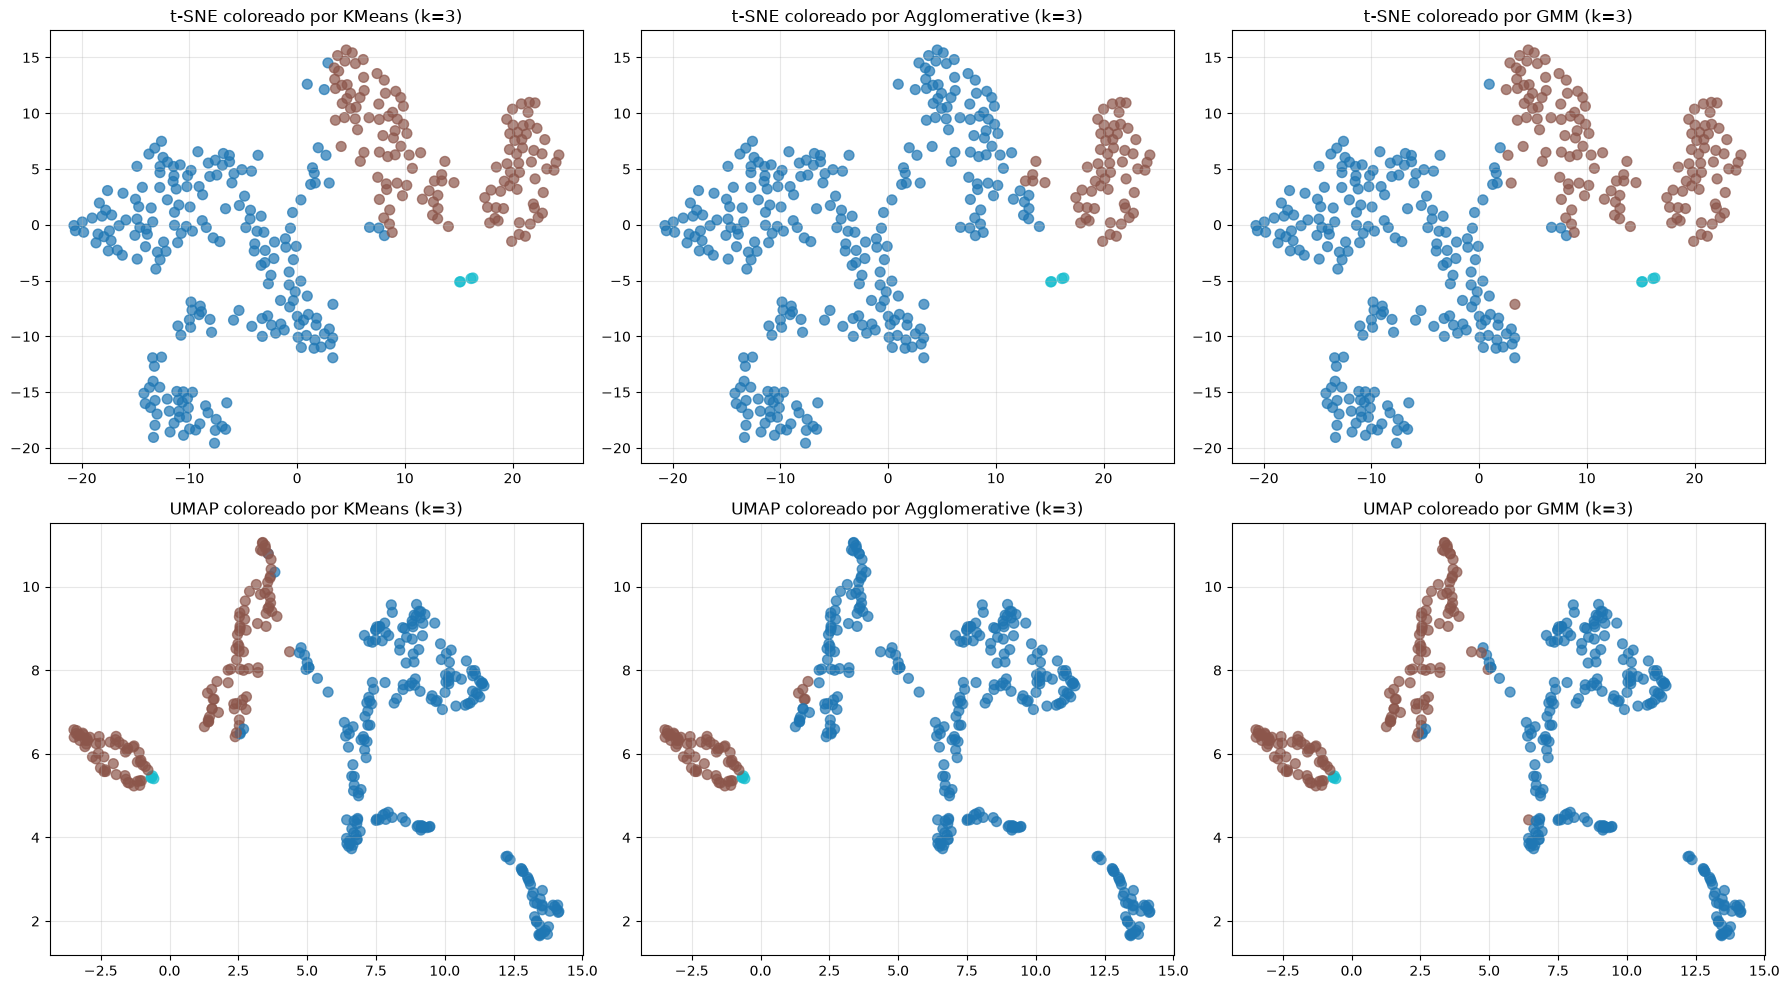

In [12]:
for k in (2, 3): 
    labels_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(
        X_scaled
    )
    labels_agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(
        X_scaled
    )
    labels_gmm = (
        GaussianMixture(n_components=k, random_state=42, n_init=5)
        .fit(X_scaled)
        .predict(X_scaled)
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    label_sets = [
        ("KMeans", labels_kmeans),
        ("Agglomerative", labels_agg),
        ("GMM", labels_gmm),
    ]

    for col, (name, labels) in enumerate(label_sets):
        axes[0, col].scatter(
            embedding_tsne[:, 0],
            embedding_tsne[:, 1],
            c=labels,
            cmap="tab10",
            alpha=0.7,
            s=50,
        )
        axes[0, col].set_title(f"t-SNE coloreado por {name} (k={k})")
        axes[0, col].grid(True, alpha=0.3)

        axes[1, col].scatter(
            embedding_umap[:, 0],
            embedding_umap[:, 1],
            c=labels,
            cmap="tab10",
            alpha=0.7,
            s=50,
        )
        axes[1, col].set_title(f"UMAP coloreado por {name} (k={k})")
        axes[1, col].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

En la visualización para k=2 analizando t-SNE podemos ver que cada algoritmo intenta separar el cúmulo en la parte derecha. Igualmente, en UMAP se separa el cúmulo de la parte izquierda. Se destaca a `GMM` que separa mejor estos dos cúmulos para t-SNE y UMAP.  

Para k=3, se muestran resultados consistentes con 2 cúmulos y un microclúster que representa a los valores atípicos de clúster 2. Los resultados son más similares entre `KMeans` y `GMM`, concordando con **Adjusted Rand Index**.  

_k_=2 muestra un clúster débil y uno fuerte, y, en cambio, _k_=3 ofrece dos clústers más fuertes con cuatro outliers.

Las visualizaciones muestran una separación similar entre _k_=2 y _k_=3 con la diferencia de los cuatro valores típicos que representan el tercer clúster.

---

## Análisis de clústers para _k_=3

Se realizará un análisis de las características de media, desviación estándar, rango y coeficiente de variación de los tres algoritmos con _k_=3 fijo.

In [19]:
labels_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(
    X_scaled
)
labels_agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(
    X_scaled
)
labels_gmm = (
    GaussianMixture(n_components=3, random_state=42, n_init=5)
    .fit(X_scaled)
    .predict(X_scaled)
)

df_clusters = X_raw.copy()
resids = data["NMR"]["g3_CHOL_body_resids"]
df_clusters.set_index(resids)

df_clusters["kmeans"] = labels_kmeans
df_clusters["agglomerative"] = labels_agg
df_clusters["gmm"] = labels_gmm

df_clusters.head()

,mean_body,std_body,range_body,cv_body,kmeans,agglomerative,gmm
0,0.000021,0.000432,0.058305,20.789230,0,0,0
1,0.000017,0.000432,0.058219,26.101698,0,0,0
2,0.000021,0.000432,0.058261,21.044260,0,0,0
3,0.000021,0.000432,0.058256,20.823084,0,0,0
4,0.000022,0.000432,0.058326,19.243490,0,0,1


In [22]:
features = ["mean_body", "std_body", "range_body", "cv_body"]
methods = ["kmeans", "agglomerative", "gmm"]

df_long = df_clusters.melt(
    id_vars=features,
    value_vars=methods,
    var_name="method",
    value_name="cluster"
)

table = df_long.groupby(["method", "cluster"])[features].agg(
    ["mean", "std", "count", "min", "max"]
)

table

mean_body                                      std_body  \
                           mean       std count       min       max      mean   
method        cluster                                                           
agglomerative 0        0.000020  0.000002   278  0.000012  0.000025  0.000432   
              1        0.000028  0.000002    60  0.000025  0.000035  0.000431   
              2        0.000024  0.000003     4  0.000020  0.000027  0.000421   
gmm           0        0.000019  0.000002   203  0.000012  0.000022  0.000432   
              1        0.000026  0.000003   135  0.000020  0.000035  0.000432   
              2        0.000024  0.000003     4  0.000020  0.000027  0.000421   
kmeans        0        0.000019  0.000002   208  0.000012  0.000022  0.000432   
              1        0.000026  0.000003   130  0.000022  0.000035  0.000432   
              2        0.000024  0.000003     4  0.000020  0.000027  0.000421   

                                                              range_body  \
                                std count       min       max       mean   
method        cluster                                                      
agglomerative 0        2.728871e-07   278  0.000430  0.000432   0.058243   
              1        6.453723e-07    60  0.000427  0.000432   0.058187   
              2        2.593574e-06     4  0.000418  0.000424   0.057770   
gmm           0        2.312354e-07   203  0.000430  0.000432   0.058243   
              1        5.218117e-07   135  0.000427  0.000432   0.058218   
              2        2.593574e-06     4  0.000418  0.000424   0.057770   
kmeans        0        2.813992e-07   208  0.000430  0.000432   0.058243   
              1        4.976922e-07   130  0.000427  0.000432   0.058217   
              2        2.593574e-06     4  0.000418  0.000424   0.057770   

                                                             cv_body  \
                            std count       min       max       mean   
method        cluster                                                  
agglomerative 0        0.000064   278  0.057986  0.058380  21.439911   
              1        0.000087    60  0.057889  0.058333  15.296377   
              2        0.000280     4  0.057427  0.058022  18.135649   
gmm           0        0.000065   203  0.057986  0.058380  22.545342   
              1        0.000079   135  0.057889  0.058349  17.047211   
              2        0.000280     4  0.057427  0.058022  18.135649   
kmeans        0        0.000065   208  0.057986  0.058380  22.477105   
              1        0.000080   130  0.057889  0.058349  16.944923   
              2        0.000280     4  0.057427  0.058022  18.135649   

                                                             
                            std count        min        max  
method        cluster                                        
agglomerative 0        2.689704   278  17.362243  34.582742  
              1        1.168925    60  12.448402  17.378208  
              2        2.531310     4  15.514573  21.312622  
gmm           0        2.282985   203  19.482286  34.582742  
              1        1.818913   135  12.448402  21.190621  
              2        2.531310     4  15.514573  21.312622  
kmeans        0        2.299882   208  19.243490  34.582742  
              1        1.769334   130  12.448402  19.513483  
              2        2.531310     4  15.514573  21.312622

Las características `mean_body` y `cv_body` muestran más diferencias entre los grupos: El clúster 0 muestra un promedio de `mean_body` bajo (`~1.9e-5 - 2e-5`) y promedio de `cv_body` alto (`~22`) comparado con los demás grupos, mientras que el clúster 1 muestra en promedio valores todavía más altos de `mean_body` (`~2.4e-5 - 2.6e-5`) y los valores más bajos de `cv_body` en promedio (`~15 - 17`). El clúster 2 es consistente entre los tres algoritmos, con la distinción en `std_body` que tiene valores más altos para su desviación estándar que los demás grupos (`~2.6e-6` vs `(~2.3e-7 - 6.45e-7)`). Aún así, `std_body` y `range_body` no muestran más diferencias significativas entre los grupos. 

In [31]:
df_clusters[df_clusters["kmeans"] == 2].index

Index([22, 64, 193, 235], dtype='int64')

In [30]:
df_clusters[df_clusters["agglomerative"] == 2].index

Index([22, 64, 193, 235], dtype='int64')

In [32]:
df_clusters[df_clusters["gmm"] == 2].index

Index([22, 64, 193, 235], dtype='int64')

In [38]:
outliers = df_clusters[df_clusters["kmeans"] == 2].index.tolist()

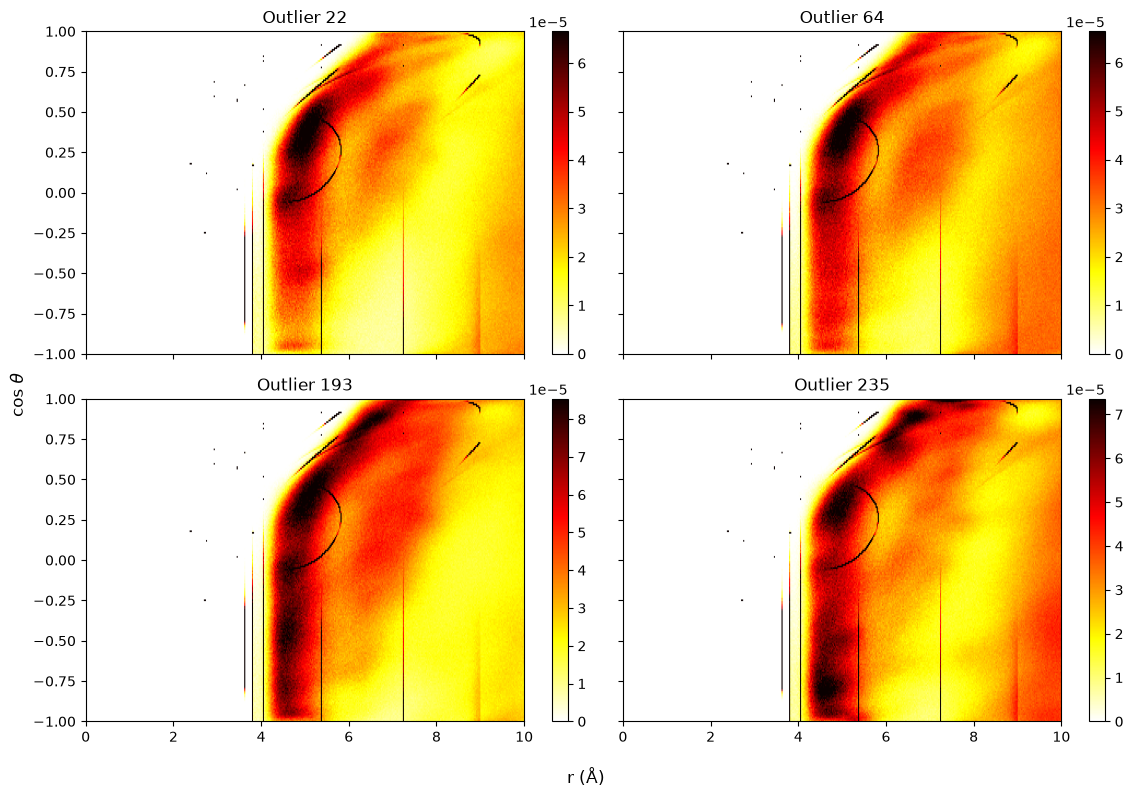

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, i in zip(axes.flat, outliers):
    im = ax.imshow(
        body_data[i].T,
        cmap="hot_r",
        vmin=0,
        vmax=np.quantile(body_data[i], 0.99),
        origin="lower",
        aspect="auto",
        extent=[0, 10, -1, 1],
    )
    ax.set_title(f"Outlier {i}")
    fig.colorbar(im, ax=ax)

fig.supxlabel(r"r (Å)")
fig.supylabel(r"$\cos\,\theta$")
fig.tight_layout()
plt.show()

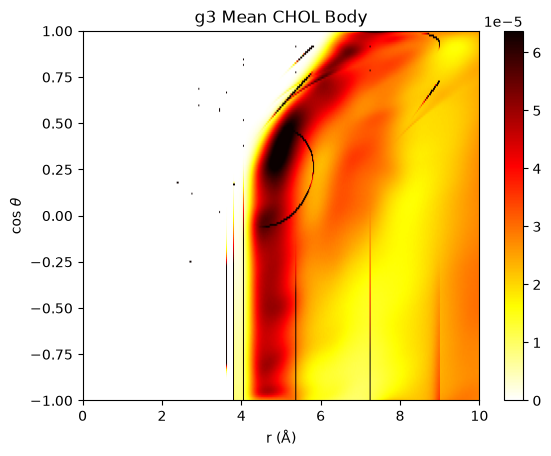

In [62]:
fig, ax = plt.subplots()

mean_map = body_data.mean(axis=0)
im = ax.imshow(
mean_map.T,
cmap="hot_r",
vmin=0,
vmax=np.quantile(mean_map, 0.99),
origin="lower",
aspect="auto",
extent=[0, 10, -1, 1],
)

fig.colorbar(im, ax=ax)
ax.set_title("g3 Mean CHOL Body")
ax.set_xlabel(r"r (Å)")
ax.set_ylabel(r"$\cos\,\theta$")
plt.show()

In [66]:
features = ["mean_body", "std_body", "range_body", "cv_body"]

outliers = df_clusters.index[df_clusters["kmeans"] == 2]
print("Outliers:", list(outliers))

print(df_clusters.loc[outliers, features])

print(df_clusters.drop(outliers)[features].describe())

print(df_clusters[features].rank(pct=True).loc[outliers])

Outliers: [22, 64, 193, 235]
     mean_body  std_body  range_body    cv_body
22    0.000020  0.000424    0.057974  21.312622
64    0.000022  0.000422    0.058022  18.883587
193   0.000027  0.000418    0.057427  15.514573
235   0.000025  0.000420    0.057656  16.831816
        mean_body      std_body  range_body     cv_body
count  338.000000  3.380000e+02  338.000000  338.000000
mean     0.000022  4.317247e-04    0.058233   20.349343
std      0.000004  4.083507e-07    0.000072    3.422373
min      0.000012  4.272741e-04    0.057889   12.448402
25%      0.000019  4.315999e-04    0.058189   18.109668
50%      0.000021  4.317956e-04    0.058246   20.804317
75%      0.000024  4.319492e-04    0.058284   22.196282
max      0.000035  4.322671e-04    0.058380   34.582742
     mean_body  std_body  range_body   cv_body
22    0.312865  0.011696    0.011696  0.593567
64    0.622807  0.008772    0.020468  0.350877
193   0.871345  0.002924    0.002924  0.084795
235   0.824561  0.005848    0.005848  0